# Template Matching Classification Analysis

**Purpose:** Test if neural population activity patterns can discriminate between:
1. **Odor identities** - Can neurons tell apart 7 different odors?
2. **Valence categories** - Can valence neurons distinguish attractive from aversive stimuli?

**Method:**
- **Template matching:** Classify trials based on cosine distance to mean response templates
- **Cross-validation:** Stratified K-fold for robust accuracy estimates
- **Permutation testing:** 1000 shuffles to assess statistical significance
- **Meta-analysis:** Fisher's method to combine p-values across 10 fish
- **Multiple testing:** FDR correction across ~30-40 brain areas

**Key Question:** Which brain areas contain decodable information about stimulus identity or valence?

---

## Notebook Structure:
1. Setup & Configuration
2. Helper Functions
3. Odor Template Matching (7 odors × 10 fish × ~35 areas)
4. Valence Template Matching (2 categories × 10 fish × ~35 areas)
5. Results & Visualization


## 1. Setup & Configuration


In [1]:
# Imports
import pandas as pd
import numpy as np
import json
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import io

import warnings
warnings.filterwarnings('ignore')



### Configuration Parameters


In [9]:
# ============================================================================
# FILE PATHS
# ============================================================================
NEURAL_DATA_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_wb_population_early_response_vector_50%.h5'
NMLF_MASK_PATH = '/Volumes/LaCie/area_masks/area_masks_mapzebrain/nMLF.tiff'
POS_VALENCE_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_positive_correlations_25s_no_HCl_1000_corrected.csv'
NEG_VALENCE_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_negative_correlations_25s_no_HCl_1000_corrected.csv'
OUTPUT_DIR = '/Volumes/LaCie/larval_HuC/imaging'

# ============================================================================
# FISH IDENTIFIERS (10 fish, forebrain + hindbrain per fish)
# ============================================================================
FISH_IDS = [
    ['230713_fb', '230713_hb'], ['230714_fb', '230714_hb'],
    ['230720_fb', '230720_hb'], ['230727_fb', '230727_hb'],
    ['230728_fb', '230728_hb'], ['230810_fb', '230810_hb'],
    ['230811_fb', '230811_hb'], ['230817_fb', '230817_hb'],
    ['230818_fb', '230818_hb'], ['230919_fb', '230919_hb']
]

# ============================================================================
# ODOR TEMPLATE MATCHING PARAMETERS
# ============================================================================
# 7 odors: 3 attractive, 4 aversive
ORDERED_STIMULI = [
    'fex_1',      # Food extract (attractive)
    'kw',         # Kairomone/water (attractive)
    'pro_2.5mm',  # Proline (attractive)
    'ade',        # Adenosine (aversive)
    'cad_2.5mm',  # Cadaverine (aversive)
    'ph4.5',      # Low pH (aversive)
    'qui_2.5mm'   # Quinine (aversive)
]

MIN_NEURONS_ODOR = 10      # Minimum neurons required per area
N_FOLDS_ODOR = 3           # Cross-validation folds
N_PERMUTATIONS = 1000      # Permutation test iterations

# ============================================================================
# VALENCE TEMPLATE MATCHING PARAMETERS  
# ============================================================================
# Binary classification: attractive (1) vs aversive (0)
SELECTED_STIMULI_VALENCE = ['ade', 'cad_2.5mm', 'fex_1', 'kw', 'pro_2.5mm', 'qui_2.5mm']

VALENCE_MAP = {
    # Aversive stimuli
    'ade': 0,
    'cad_2.5mm': 0,
    'qui_2.5mm': 0,
    # Attractive stimuli
    'fex_1': 1,
    'kw': 1,
    'pro_2.5mm': 1
}

MIN_NEURONS_VALENCE = 5    # Minimum neurons for valence analysis
N_FOLDS_VALENCE = 5        # Cross-validation folds
FDR_ALPHA = 0.05           # FDR significance threshold

# ============================================================================
# DISPLAY CONFIGURATION
# ============================================================================
print("✓ Configuration loaded")
print(f"  Fish: {len(FISH_IDS)}")
print(f"  Odor stimuli: {len(ORDERED_STIMULI)}")
print(f"  Valence stimuli: {len(SELECTED_STIMULI_VALENCE)}")
print(f"  Permutations: {N_PERMUTATIONS}")
print(f"  FDR alpha: {FDR_ALPHA}")


✓ Configuration loaded
  Fish: 10
  Odor stimuli: 7
  Valence stimuli: 6
  Permutations: 1000
  FDR alpha: 0.05


In [34]:
with open("/Volumes/LaCie/larval_HuC/imaging/brain_map_values/area_shorthand_dict.json", "r") as f:
    AREA_SHORTHAND = json.load(f)
print(f"✓ Area dictionary loaded: {len(AREA_SHORTHAND)} areas")

✓ Area dictionary loaded: 41 areas


### Load nMLF Area Mask


In [10]:
# Load nMLF mask (nucleus of the medial longitudinal fasciculus)
# This region is not in the standard atlas, so we manually assign neurons using a 3D mask
nMLF = io.imread(NMLF_MASK_PATH)
print(f"✓ nMLF mask loaded: shape {nMLF.shape}")


✓ nMLF mask loaded: shape (359, 974, 597)


## 2. Helper Functions

These modular functions handle:
- Spatial mask checking
- Template matching classification
- Permutation testing
- Statistical combination across fish
- Visualization utilities


### Mask Checking Function


In [4]:
def is_within_3d_mask(coordinates, mask):
    """Check if neuron coordinates fall within a 3D binary mask.
    
    Args:
        coordinates: Array or tuple [z, y, x] in voxel space
        mask: 3D binary mask array
        
    Returns:
        Boolean indicating if neuron is within mask (mask value > 0)
    """
    coordinates = np.array(coordinates, dtype=int)
    
    # Validate coordinates
    if coordinates.shape != (3,):
        return False
    
    z, y, x = coordinates
    depth, height, width = mask.shape
    
    # Check if within bounds
    if (0 <= z < depth) and (0 <= y < height) and (0 <= x < width):
        return mask[z, y, x] > 0
    
    return False

print("✓ is_within_3d_mask() defined")


✓ is_within_3d_mask() defined


### Template Matching Classification


In [5]:
def template_matching_cross_validation(X, y, labels, n_splits=3):
    """Perform template matching classification with cross-validation.
    
    Method:
      1. Split data into train/test folds (stratified to balance classes)
      2. Create templates: mean response per stimulus from training data
      3. Classify test trials: find closest template by cosine distance
      4. Calculate accuracy and confusion matrix
    
    Args:
        X: Feature matrix [n_samples × n_features] - each row is a trial
        y: Label array [n_samples] - stimulus identity for each trial
        labels: Ordered list of unique labels (for confusion matrix)
        n_splits: Number of cross-validation folds
        
    Returns:
        dict with:
          - 'cv_scores': List of accuracy per fold
          - 'mean_score': Mean accuracy across folds
          - 'confusion_matrix': Average confusion matrix
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = []
    conf_matrix_sum = np.zeros((len(labels), len(labels)))
    n_folds = 0
    
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Create templates (mean response per label in training set)
        templates = {
            label: np.mean([X_train[i] for i, lbl in enumerate(y_train) if lbl == label], axis=0)
            for label in labels
        }
        
        # Classify test samples by minimum cosine distance
        y_pred = []
        for test_sample in X_test:
            distances = {
                label: cosine_distances([test_sample], [templates[label]]).flatten()[0]
                for label in labels
            }
            y_pred.append(min(distances, key=distances.get))
        
        # Calculate metrics
        accuracy = np.mean(np.array(y_pred) == y_test)
        cv_scores.append(accuracy)
        
        # Accumulate confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        conf_matrix_sum += cm
        n_folds += 1
    
    return {
        'cv_scores': cv_scores,
        'mean_score': np.mean(cv_scores),
        'confusion_matrix': conf_matrix_sum / n_folds
    }

print("✓ template_matching_cross_validation() defined")


✓ template_matching_cross_validation() defined


### Permutation Testing


In [6]:
def permutation_test(X, y, labels, n_splits=3, n_permutations=1000):
    """Permutation test for classification significance.
    
    Null hypothesis: Labels are random (no information in neural patterns)
    
    Method:
      1. Calculate real accuracy with true labels
      2. Shuffle labels n_permutations times
      3. Calculate accuracy with shuffled labels each time
      4. P-value = proportion of shuffled accuracies >= real accuracy
    
    Args:
        X: Feature matrix
        y: True labels
        labels: Unique label values
        n_splits: CV folds
        n_permutations: Number of shuffles
        
    Returns:
        p_value: Probability of observing real accuracy under null hypothesis
    """
    # Real accuracy
    real_result = template_matching_cross_validation(X, y, labels, n_splits)
    real_accuracy = real_result['mean_score']
    
    # Generate null distribution
    null_accuracies = []
    for _ in range(n_permutations):
        shuffled_y = shuffle(y, random_state=None)  # Random shuffle each time
        perm_result = template_matching_cross_validation(X, shuffled_y, labels, n_splits)
        null_accuracies.append(perm_result['mean_score'])
    
    # Calculate p-value (one-tailed test)
    p_value = np.sum(np.array(null_accuracies) >= real_accuracy) / n_permutations
    
    return p_value

print("✓ permutation_test() defined")


✓ permutation_test() defined


### Statistical Combination Across Fish


In [7]:
def combine_fish_statistics(all_areas_dict, fdr_alpha=0.05):
    """Combine p-values across fish using Fisher's method, then FDR correct across areas.
    
    Fisher's method: Combine independent p-values into single test statistic
    FDR correction: Control false discovery rate across multiple brain areas
    
    Args:
        all_areas_dict: Dict[area_name] = [(fish_id, accuracy, p_value), ...]
        fdr_alpha: FDR significance threshold
        
    Returns:
        DataFrame with combined statistics per area, sorted by FDR-corrected p-value
    """
    combined_stats = {}
    
    # Step 1: Fisher's method per area (combine across fish)
    for area, fish_results in all_areas_dict.items():
        p_values = [p for _, _, p in fish_results]
        scores = [s for _, s, _ in fish_results]
        
        # Combine p-values using Fisher's method
        try:
            _, combined_p = combine_pvalues(p_values, method='fisher')
        except:
            combined_p = 1.0  # If combination fails, set to non-significant
        
        combined_stats[area] = {
            'combined_p': combined_p,
            'individual_pvals': p_values,
            'mean_accuracy': np.mean(scores),
            'std_accuracy': np.std(scores),
            'individual_accuracies': scores,
            'n_fish': len(fish_results)
        }
    
    # Step 2: FDR correction across areas
    areas = list(combined_stats.keys())
    p_values_array = [combined_stats[area]['combined_p'] for area in areas]
    
    _, p_corrected, _, _ = multipletests(p_values_array, alpha=fdr_alpha, method='fdr_bh')
    
    # Add FDR-corrected results
    for area, p_fdr in zip(areas, p_corrected):
        combined_stats[area]['fdr_corrected'] = p_fdr
        combined_stats[area]['is_significant'] = p_fdr < fdr_alpha
    
    # Convert to DataFrame
    records = []
    for area, stats in combined_stats.items():
        records.append({
            'area': area,
            'mean_accuracy': stats['mean_accuracy'],
            'std_accuracy': stats['std_accuracy'],
            'combined_p': stats['combined_p'],
            'fdr_corrected': stats['fdr_corrected'],
            'is_significant': stats['is_significant'],
            'n_fish': stats['n_fish']
        })
    
    df = pd.DataFrame(records).sort_values('fdr_corrected')
    
    return df

print("✓ combine_fish_statistics() defined")


✓ combine_fish_statistics() defined


### Visualization Utilities


In [8]:
def jitter(values, amount=0.05):
    """Add small random jitter to values for visualization.
    
    Prevents overlapping points in scatter plots.
    
    Args:
        values: Array of values to jitter
        amount: Maximum jitter magnitude
        
    Returns:
        Jittered values
    """
    return values + np.random.uniform(-amount, amount, len(values))

print("✓ jitter() defined")
print("\n" + "="*80)
print("All helper functions loaded successfully!")
print("="*80)


✓ jitter() defined

All helper functions loaded successfully!


## 3. Odor Template Matching Analysis

**Goal:** Test if neural population patterns can discriminate between 7 different odor identities

**Stimuli:**
- **Attractive:** fex_1, kw, pro_2.5mm
- **Aversive:** ade, cad_2.5mm, ph4.5, qui_2.5mm

**Analysis per area:**
1. Extract neurons in this brain area
2. Cross-validation: classify trials by template matching
3. Permutation test: assess significance
4. Store: accuracy, p-value, confusion matrix

**Then combine:**
- Fisher's method: combine p-values across 10 fish per area
- FDR correction: correct for ~35 brain areas


### Initialize Storage for Results


In [11]:
# Storage for results across all fish
all_odor_results = {}
all_odor_conf_matrices = {}

# Track processing
n_fish = len(FISH_IDS)
print(f"Starting odor analysis for {n_fish} fish...")
print(f"Analyzing {len(ORDERED_STIMULI)} odor stimuli")
print(f"Minimum neurons per area: {MIN_NEURONS_ODOR}")
print(f"Cross-validation folds: {N_FOLDS_ODOR}")
print(f"Permutations: {N_PERMUTATIONS}")


Starting odor analysis for 10 fish...
Analyzing 7 odor stimuli
Minimum neurons per area: 10
Cross-validation folds: 3
Permutations: 1000


### Main Processing Loop: For Each Fish


In [12]:
# Process each fish
for fish_num, (fb_id, hb_id) in enumerate(FISH_IDS, 1):
    print(f"\n{'='*80}")
    print(f"Fish {fish_num}/{n_fish}: {fb_id}, {hb_id}")
    print(f"{'='*80}")
    
    # Load forebrain and hindbrain data
    data_fb = pd.read_hdf(NEURAL_DATA_PATH, where=f'fish_id == "{fb_id}"')
    data_hb = pd.read_hdf(NEURAL_DATA_PATH, where=f'fish_id == "{hb_id}"')
    data = pd.concat([data_fb, data_hb])
    
    # Filter for odor stimuli
    stimulus_df = data[data['stimulus'].isin(ORDERED_STIMULI)].copy()
    
    # Parse coordinates and assign nMLF neurons
    stimulus_df['coords'] = stimulus_df['coords_serialised'].apply(
        lambda x: np.asarray(json.loads(x))
    )
    stimulus_df.drop('coords_serialised', axis=1, inplace=True, errors='ignore')
    stimulus_df['area'] = stimulus_df.apply(
        lambda row: 'nMLF' if is_within_3d_mask(row['coords'], nMLF) else row['area'], 
        axis=1
    )
    
    # Get unique areas for this fish
    unique_areas = stimulus_df['area'].unique()
    fish_results = {}
    fish_conf_matrices = {}
    
    print(f"  Found {len(unique_areas)} brain areas")
    
    # Process each brain area
    for area_num, area in enumerate(unique_areas, 1):
        area_df = stimulus_df.query("area == @area")
        
        # Pivot to matrix: neurons × (stimulus, trial)
        df_resp = area_df.pivot_table(
            index=['fish_id', 'neuron_id'], 
            columns=['stimulus', 'trial_number'], 
            values='resp'
        )
        
        # Sort columns by stimulus order
        df_resp = df_resp.reindex(
            columns=sorted(df_resp.columns, key=lambda x: ORDERED_STIMULI.index(x[0]))
        )
        
        # Remove neurons with NaN values
        resp_clean = df_resp.dropna()
        
        # Check minimum neuron requirement
        if len(resp_clean) < MIN_NEURONS_ODOR:
            continue
        
        print(f"    [{area_num}/{len(unique_areas)}] {area}: {len(resp_clean)} neurons")
        
        # Prepare data for classification
        X = resp_clean.values.T  # Transpose: trials × neurons
        y = np.array([col[0] for col in resp_clean.columns])  # Stimulus labels
        
        # Template matching with cross-validation
        cv_result = template_matching_cross_validation(
            X, y, ORDERED_STIMULI, n_splits=N_FOLDS_ODOR
        )
        mean_accuracy = cv_result['mean_score']
        
        # Permutation test for significance
        p_value = permutation_test(
            X, y, ORDERED_STIMULI, 
            n_splits=N_FOLDS_ODOR, 
            n_permutations=N_PERMUTATIONS
        )
        
        # Store results
        fish_results[area] = {
            'accuracy_score': mean_accuracy,
            'p_value': p_value,
            'n_neurons': len(resp_clean)
        }
        
        fish_conf_matrices[area] = {
            'confusion_matrix': cv_result['confusion_matrix'],
            'stimulus_labels': ORDERED_STIMULI
        }
        
        print(f"      Accuracy: {mean_accuracy:.3f}, p-value: {p_value:.4f}")
    
    # Store fish results
    fish_key = f"{fb_id}_{hb_id}"
    all_odor_results[fish_key] = fish_results
    all_odor_conf_matrices[fish_key] = fish_conf_matrices
    
    print(f"  Completed {len(fish_results)} areas for this fish")

print(f"\n{'='*80}")
print(f"✓ Odor analysis complete for all {n_fish} fish")
print(f"{'='*80}")



Fish 1/10: 230713_fb, 230713_hb
  Found 39 brain areas
    [1/39] dorsal_habenula: 211 neurons
      Accuracy: 0.762, p-value: 0.0000
    [2/39] ventral_habenula: 277 neurons
      Accuracy: 0.619, p-value: 0.0000
    [3/39] not_assigned: 844 neurons
      Accuracy: 0.857, p-value: 0.0000
    [4/39] pretectum: 473 neurons
      Accuracy: 0.524, p-value: 0.0000
    [5/39] tori: 46 neurons
      Accuracy: 0.238, p-value: 0.1990
    [6/39] tectum: 1756 neurons
      Accuracy: 0.143, p-value: 0.5330
    [7/39] superior_dorsal_med_ob: 2355 neurons
      Accuracy: 0.190, p-value: 0.3530
    [8/39] secondary_gustatory_nucleus: 263 neurons
      Accuracy: 0.238, p-value: 0.2230
    [9/39] tegmentum: 310 neurons
      Accuracy: 0.143, p-value: 0.5400
    [10/39] pallium: 1087 neurons
      Accuracy: 0.905, p-value: 0.0000
    [11/39] nucleus_isthmi: 941 neurons
      Accuracy: 0.190, p-value: 0.3900
    [12/39] eminentia_thalami: 117 neurons
      Accuracy: 0.857, p-value: 0.0000
    [13/39] d

### Statistical Combination Across Fish


In [14]:
# Reorganize data by area (across fish)
all_areas_odor = {}

for fish_id, fish_results in all_odor_results.items():
    for area_name, area_results in fish_results.items():
        mean_score = area_results['accuracy_score']
        p_value = area_results['p_value']
        
        if area_name not in all_areas_odor:
            all_areas_odor[area_name] = []
        
        all_areas_odor[area_name].append((fish_id, mean_score, p_value))

print(f"\nCombining statistics across fish...")
print(f"  Total areas analyzed: {len(all_areas_odor)}")

# Combine using Fisher's method + FDR correction
df_odor_combined = combine_fish_statistics(all_areas_odor, fdr_alpha=FDR_ALPHA)

# Display results
print(f"\n{'='*80}")
print("ODOR TEMPLATE MATCHING RESULTS")
print(f"{'='*80}")
print(f"\nSignificant areas (FDR < {FDR_ALPHA}):")
sig_areas = df_odor_combined[df_odor_combined['is_significant']]
print(f"  {len(sig_areas)}/{len(df_odor_combined)} areas")

if len(sig_areas) > 0:
    print(f"\nTop 10 most significant areas:")
    print(sig_areas[['area', 'mean_accuracy', 'fdr_corrected']].head(10).to_string(index=False))

print(f"\nAccuracy statistics:")
print(f"  Mean: {df_odor_combined['mean_accuracy'].mean():.3f}")
print(f"  Range: {df_odor_combined['mean_accuracy'].min():.3f} - {df_odor_combined['mean_accuracy'].max():.3f}")
print(f"  Chance: {1/len(ORDERED_STIMULI):.3f} (1/{len(ORDERED_STIMULI)} stimuli)")



Combining statistics across fish...
  Total areas analyzed: 39

ODOR TEMPLATE MATCHING RESULTS

Significant areas (FDR < 0.05):
  26/39 areas

Top 10 most significant areas:
                     area  mean_accuracy  fdr_corrected
          dorsal_habenula       0.442857            0.0
           superior_raphe       0.214286            0.0
               cerebellum       0.171429            0.0
     rostral_hypothalamus       0.395238            0.0
intermediate_hypothalamus       0.409524            0.0
                 preoptic       0.661905            0.0
              prethalamus       0.542857            0.0
               subpallium       0.728571            0.0
           olfactory_bulb       0.871429            0.0
          dorsal_thalamus       0.371429            0.0

Accuracy statistics:
  Mean: 0.334
  Range: 0.132 - 0.871
  Chance: 0.143 (1/7 stimuli)


### Visualization: Odor Results


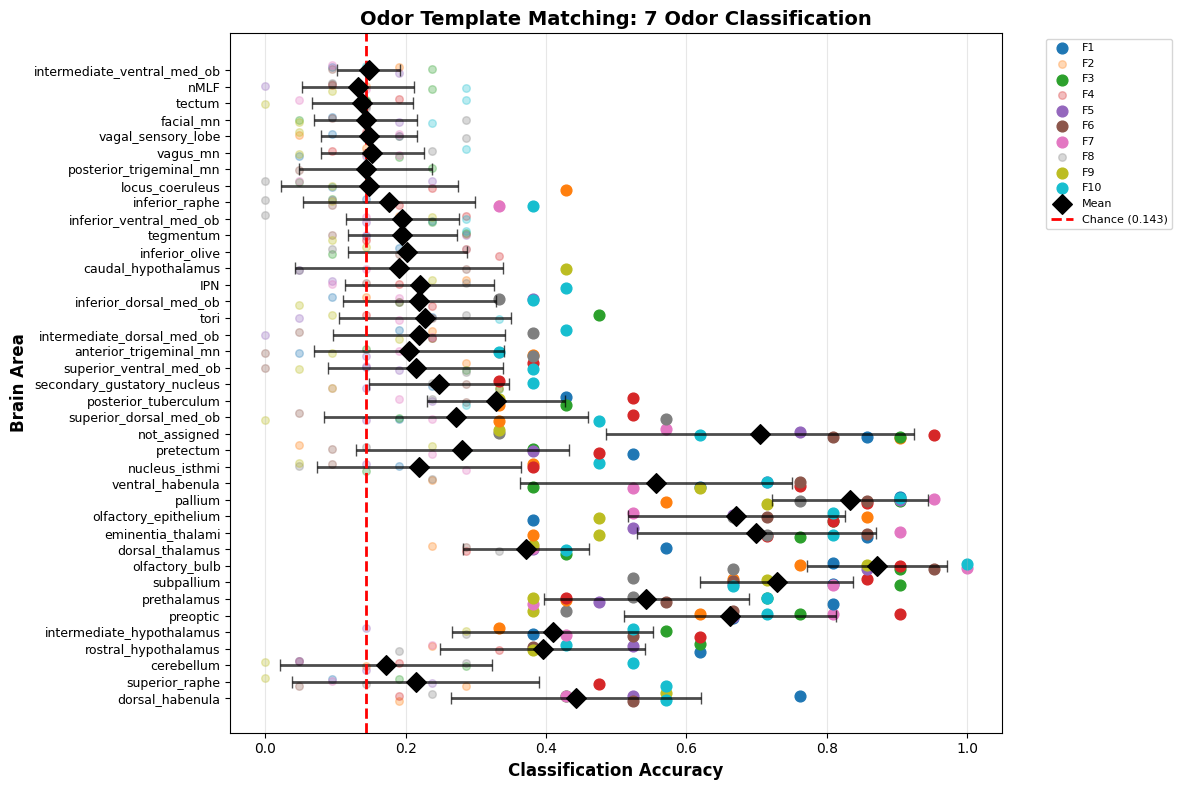

✓ Visualization complete


In [45]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for plotting
area_indices = {area: i for i, area in enumerate(df_odor_combined['area'])}
sorted_areas = list(df_odor_combined['area'])

# Color map for fish
fish_colors = plt.cm.tab10(np.linspace(0, 1, len(FISH_IDS)))
simplified_fish_ids = {f"{fb}_{hb}": f"F{i+1}" for i, (fb, hb) in enumerate(FISH_IDS)}

# Plot individual fish results
labels_handled = set()
for area in sorted_areas:
    if area not in all_areas_odor:
        continue
    
    fish_results = all_areas_odor[area]
    y_values = [area_indices[area]] * len(fish_results)
    jittered_y = jitter(np.array(y_values, dtype=float), amount=0.3)
    
    for y, (fish_id, score, p_value) in zip(jittered_y, fish_results):
        simple_id = simplified_fish_ids[fish_id]
        fish_idx = list(simplified_fish_ids.values()).index(simple_id)
        
        # Alpha and size based on significance
        alpha = 1.0 if p_value < 0.05 else 0.3
        marker_size = 60 if p_value < 0.05 else 30
        
        if simple_id not in labels_handled:
            ax.scatter(score, y, c=[fish_colors[fish_idx]], 
                      alpha=alpha, s=marker_size, label=simple_id)
            labels_handled.add(simple_id)
        else:
            ax.scatter(score, y, c=[fish_colors[fish_idx]], 
                      alpha=alpha, s=marker_size)

# Plot mean ± std
means = [df_odor_combined[df_odor_combined['area']==area]['mean_accuracy'].values[0] 
         for area in sorted_areas]
stds = [df_odor_combined[df_odor_combined['area']==area]['std_accuracy'].values[0] 
        for area in sorted_areas]

ax.errorbar(means, range(len(sorted_areas)), xerr=stds,
            fmt='none', ecolor='black', elinewidth=2, capsize=4, alpha=0.7)
ax.scatter(means, range(len(sorted_areas)), c='black', s=100, 
          marker='D', zorder=10, label='Mean')

# Chance level
ax.axvline(1/len(ORDERED_STIMULI), color='red', linestyle='--', 
          linewidth=2, label=f'Chance ({1/len(ORDERED_STIMULI):.3f})')

# Formatting
ax.set_yticks(range(len(sorted_areas)))
ax.set_yticklabels(sorted_areas, fontsize=9)
ax.set_xlabel('Classification Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Brain Area', fontsize=12, fontweight='bold')
ax.set_title(f'Odor Template Matching: {len(ORDERED_STIMULI)} Odor Classification', 
            fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


In [130]:

def plot_classification_accuracy_boxplot(data, areas_to_plot, area_order, pvals, reference_area=None):
    """Create boxplot of classification accuracy by brain area.

    Args:
        data: DataFrame with columns ['area', 'classification_accuracy']
        areas_to_plot: List of area codes to include
        area_order: List defining the x-axis order
        pvals: Dict mapping area codes to p-values
        reference_area: Optional area to skip significance annotation for

    Returns:
        matplotlib.figure.Figure
    """
    # Area color palette
    palette = {
        "OB": "#16327F", "OE": "#000000", "Pal": "#377DA3", "SubP": "#58C8FE",
        "PT": "#EF4066", "dHb": "#663200", "vHb": "#933264", "POA": "#8C8C00",
        "PTh": "#1E7F1D", "EmT": "#6CDA60", "HR": "#D9D900", "HI": "#EB7F25"
    }

    # Filter data
    plot_data = data[data['area'].isin(areas_to_plot)].copy()

    # Create figure
    fig = plt.figure(figsize=(10, 6), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    # Draw boxplot
    ax = sns.boxplot(
        data=plot_data,
        x='area',
        y='classification_accuracy',
        order=area_order,
        color="white",
        width=0.5,
        showcaps=False,
        showfliers=False,
        boxprops={'edgecolor': 'black', 'linewidth': 3},
        whiskerprops={'color': 'black', 'linewidth': 3},
        capprops={'color': 'black', 'linewidth': 3},
        medianprops={'color': 'black', 'linewidth': 3}
    )

    # Get plotted areas
    plotted_areas = [area for area in area_order if area in plot_data['area'].unique()]

    # Recolor boxes and lines
    lines = ax.get_lines()
    num_boxes = len(plotted_areas)
    num_lines_per_box = len(lines) // num_boxes if num_boxes > 0 else 0

    for i, area in enumerate(plotted_areas):
        color = palette[area]

        # Update box border
        box = ax.patches[i]
        box.set_edgecolor(color)
        box.set_linewidth(2.7)
        box.set_facecolor("none")

        # Update whiskers
        for line in lines[i * num_lines_per_box: i * num_lines_per_box + 2]:
            line.set_color(color)
            line.set_linewidth(2.5)

        # Update caps
        for line in lines[i * num_lines_per_box + 2: i * num_lines_per_box + 4]:
            line.set_color(color)
            line.set_linewidth(2.5)

        # Update median
        if i * num_lines_per_box + 4 < len(lines):
            median = lines[i * num_lines_per_box + 4]
            median.set_color(color)
            median.set_linewidth(3)

    # Color x-axis labels to match boxes
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24, rotation=45, ha='center')
    for label, area in zip(ax.get_xticklabels(), plotted_areas):
        label.set_color(palette[area])

   # Add jittered scatter points (open circles)
    rng = np.random.default_rng(42)
    
    for i, area in enumerate(plotted_areas):
        area_data = plot_data[plot_data['area'] == area]['classification_accuracy'].values
        
        # small horizontal jitter
        jittered_x = rng.normal(loc=i, scale=0.1, size=len(area_data))
        
        ax.scatter(
            jittered_x,
            area_data,
            facecolors='white',     # open circle
            edgecolors='black',     # black outline
            s=55,
            alpha=0.5,
            linewidth=1.2,
            zorder=3
    )

    # Add significance annotations
    y_pos = 1.03
    for i, area in enumerate(area_order):
        if reference_area is not None and area == reference_area:
            continue

        p_val = pvals.get(area, 1.0)

        if p_val < 0.001:
            significance = '***'
        elif p_val < 0.01:
            significance = '**'
        elif p_val < 0.05:
            significance = '*'
        else:
            significance = 'ns'

        if area in plotted_areas:
            ax.text(
                i, y_pos, significance,
                ha='center', va='bottom',
                fontsize=22, color='black', weight='bold'
            )

    # Styling
    ax.set_xlabel('')
    ax.set_ylabel('Classification Accuracy', fontsize=30)
    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.tick_params(axis='both', labelsize=30)
    ax.tick_params(axis='x', labelsize=32)
    ax.tick_params(axis='x', width=2)
    ax.tick_params(axis='y', width=2)

    # Clean up spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    plt.tight_layout()
    return fig

In [131]:
# -------------------------
# 1. Convert nested dict to dataframe
# -------------------------
rows = []

for fish_id, area_dict in all_odor_results.items():
    for area, metrics in area_dict.items():
        rows.append({
            'fish_id': fish_id,
            'area_full': area,
            'classification_accuracy': metrics.get('accuracy_score', None),
            'decoder_p_value': metrics.get('p_value', None),
            'n_neurons': metrics.get('n_neurons', None)
        })

area_fish_classification_accuracy = pd.DataFrame(rows)

In [132]:
area_fish_classification_accuracy['area'] = (
    area_fish_classification_accuracy['area_full'].map(AREA_SHORTHAND))

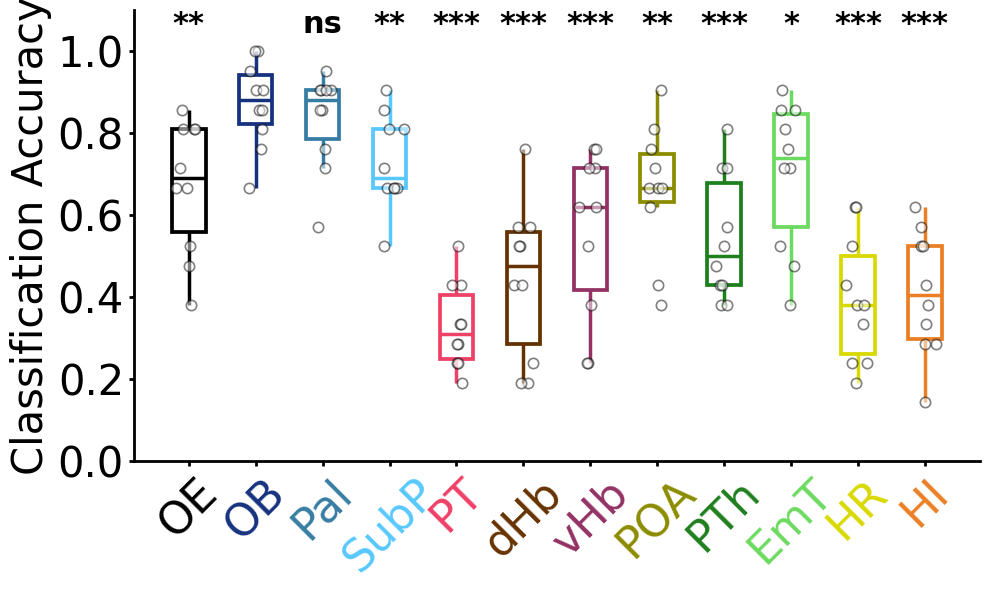

In [133]:
from scipy.stats import mannwhitneyu
import pandas as pd

area_fish_classification_accuracy = area_fish_classification_accuracy.dropna(subset=['area'])

# -------------------------
# 3. Statistics
# -------------------------
REFERENCE_AREA = "OB"
STATISTICAL_TEST = "greater"

areas = area_fish_classification_accuracy['area'].unique()

reference_data = area_fish_classification_accuracy[
    area_fish_classification_accuracy['area'] == REFERENCE_AREA
]['classification_accuracy']

pvals = {}
for area in areas:
    if area == REFERENCE_AREA:
        continue

    area_data = area_fish_classification_accuracy[
        area_fish_classification_accuracy['area'] == area
    ]['classification_accuracy']

    if len(area_data) > 0:
        stat, p = mannwhitneyu(reference_data, area_data, alternative=STATISTICAL_TEST)
        pvals[area] = p

pval_df = pd.DataFrame.from_dict(pvals, orient='index', columns=['p_value']).reset_index()
pval_df = pval_df.rename(columns={'index': 'area'})

area_fish_classification_accuracy = area_fish_classification_accuracy.merge(
    pval_df, on='area', how='left'
)

# -------------------------
# 4. Plot
# -------------------------
area_order = ["OE", "OB", "Pal", "SubP", "PT", "dHb", "vHb", "POA", "PTh", "EmT", "HR", "HI"]

fig = plot_classification_accuracy_boxplot(
    data=area_fish_classification_accuracy,
    areas_to_plot=area_order,
    area_order=area_order,
    pvals=pvals,
    reference_area=REFERENCE_AREA
)

fig.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/stimulus_classification_OB_VS_areas_early_resp.svg", format="svg", dpi=300, bbox_inches="tight")

In [54]:
from scipy.stats import spearmanr, pearsonr

# Spearman (recommended)
r_s, p_s = spearmanr(
    df['n_neurons'],
    df['classification_accuracy']
)

print(f"Spearman r = {r_s:.3f}, p = {p_s:.3f}")

# Optional: Pearson (just for comparison)
r_p, p_p = pearsonr(
    df['n_neurons'],
    df['classification_accuracy']
)

print(f"Pearson r = {r_p:.3f}, p = {p_p:.3f}")

Spearman r = 0.160, p = 0.002
Pearson r = 0.038, p = 0.461


In [127]:
df.columns

Index(['fish_id', 'area_full', 'classification_accuracy', 'decoder_p_value',
       'n_neurons', 'fish_id_clean'],
      dtype='object')

In [128]:
df.groupby('area_full')['n_neurons'].describe()

,count,mean,std,min,25%,50%,75%,max
area_full,,,,,,,,
IPN,8.0,80.250000,34.923386,29.0,56.50,88.0,107.50,123.0
anterior_trigeminal_mn,10.0,107.200000,41.416046,65.0,74.50,102.0,118.25,192.0
caudal_hypothalamus,5.0,28.800000,17.977764,10.0,20.00,26.0,30.00,58.0
cerebellum,10.0,900.400000,179.918624,629.0,795.75,888.5,1026.25,1165.0
dorsal_habenula,10.0,156.800000,31.940222,122.0,131.50,147.0,167.25,211.0
dorsal_thalamus,10.0,510.700000,248.058259,240.0,351.25,422.0,659.75,1030.0
eminentia_thalami,10.0,136.200000,47.974067,60.0,108.75,138.5,154.25,231.0
facial_mn,10.0,179.300000,71.552700,77.0,128.75,178.0,225.00,277.0
inferior_dorsal_med_ob,10.0,1998.900000,684.921804,1257.0,1517.25,1828.0,2455.25,3405.0


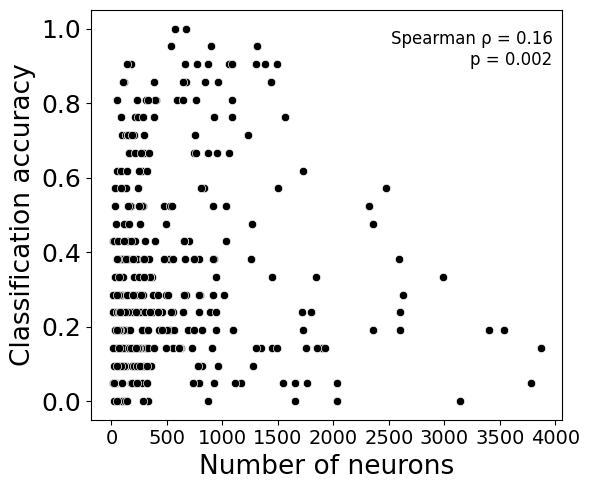

In [123]:

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='n_neurons',
    y='classification_accuracy',
    color='black'
)

plt.text(
    0.98, 0.95,
    f"Spearman ρ = {r_s:.2f}\np = {p_s:.3f}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=12
)

plt.xlabel("Number of neurons", fontsize=19)
plt.xticks(fontsize=14)
plt.ylabel("Classification accuracy", fontsize=19)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

### Save Odor Results


In [50]:

rows = []

for fish_id, area_dict in all_odor_results.items():
    for area, metrics in area_dict.items():
        rows.append({
            'fish_id': fish_id,
            'area_full': area,
            'classification_accuracy': float(metrics['accuracy_score']),
            'decoder_p_value': float(metrics['p_value']),
            'n_neurons': metrics['n_neurons']
        })

df = pd.DataFrame(rows)

In [51]:
df['fish_id_clean'] = df['fish_id'].str[:6]

In [134]:
df.to_csv('classification_accuracy_per_fish_early_resp.csv', index=False)

In [ ]:
# Save combined results
output_file_odor = f"{OUTPUT_DIR}/combined_fisher_accuracy_confusion_{len(ORDERED_STIMULI)}odors_refactored.csv"
df_odor_combined.to_csv(output_file_odor, index=False)

print(f"✓ Odor results saved to:")
print(f"  {output_file_odor}")
print(f"  Rows: {len(df_odor_combined)}")
print(f"  Significant areas: {df_odor_combined['is_significant'].sum()}")


### Confusion Matrix Analysis (Odor)

Confusion matrices reveal **which odors are systematically confused** with each other.

- **High diagonal values:** Good discrimination
- **Off-diagonal patterns:** Systematic confusions
  - Attractive odors confused with each other?
  - Aversive odors confused with each other?
  
We'll visualize confusion matrices for:
1. **Each fish individually** (to see consistency)
2. **Combined across all fish** (average pattern)


#### Aggregate Confusion Matrix Across All Fish


In [17]:
# Aggregate confusion matrices across all fish and areas
aggregate_cm = np.zeros((len(ORDERED_STIMULI), len(ORDERED_STIMULI)))
n_matrices = 0

for fish_id, fish_conf_dict in all_odor_conf_matrices.items():
    for area, conf_data in fish_conf_dict.items():
        cm = conf_data['confusion_matrix']
        aggregate_cm += cm
        n_matrices += 1

# Average across all
aggregate_cm_avg = aggregate_cm / n_matrices

print(f"Aggregated {n_matrices} confusion matrices")
print(f"  From {len(all_odor_conf_matrices)} fish")
print(f"  Across {len(all_areas_odor)} unique areas")


Aggregated 370 confusion matrices
  From 10 fish
  Across 39 unique areas


#### Visualize Aggregate Confusion Matrix


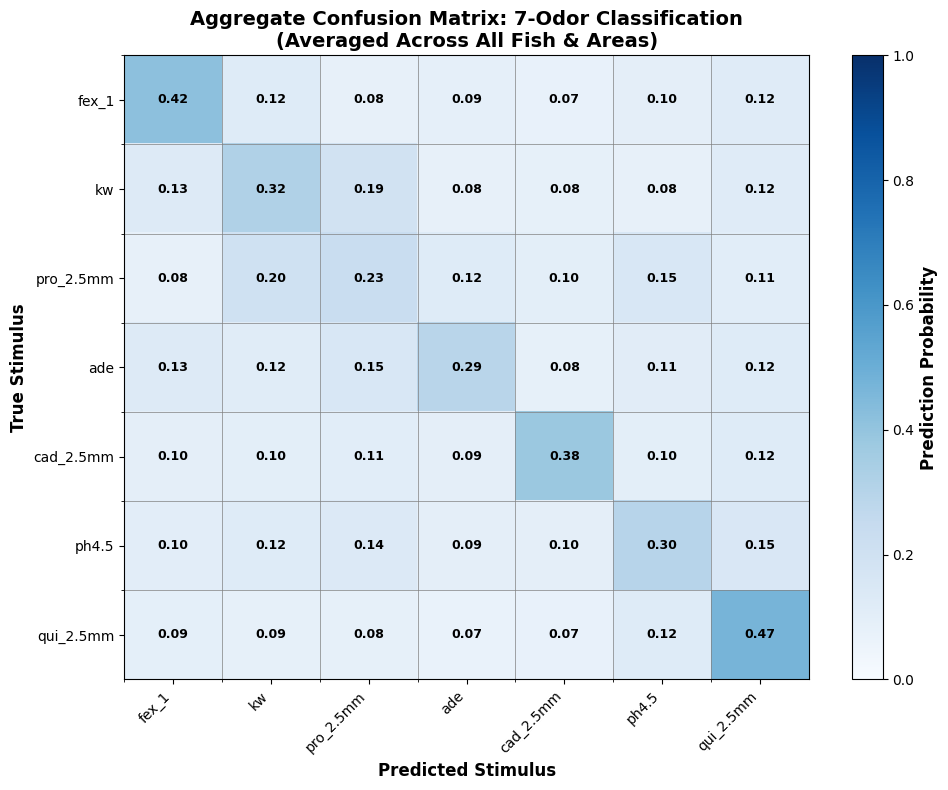


✓ Aggregate confusion matrix plotted

Interpretation:
  - High diagonal = good discrimination
  - Off-diagonal blocks = systematic confusions
  - Chance level = 0.143 (1/7)


In [18]:
# Plot aggregate confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Normalize by row (true label) to show percentages
cm_normalized = aggregate_cm_avg / aggregate_cm_avg.sum(axis=1, keepdims=True)

# Plot
im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto', vmin=0, vmax=1)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Prediction Probability', fontsize=12, fontweight='bold')

# Labels
ax.set_xticks(range(len(ORDERED_STIMULI)))
ax.set_yticks(range(len(ORDERED_STIMULI)))
ax.set_xticklabels(ORDERED_STIMULI, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ORDERED_STIMULI, fontsize=10)
ax.set_xlabel('Predicted Stimulus', fontsize=12, fontweight='bold')
ax.set_ylabel('True Stimulus', fontsize=12, fontweight='bold')
ax.set_title('Aggregate Confusion Matrix: 7-Odor Classification\n(Averaged Across All Fish & Areas)', 
            fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(ORDERED_STIMULI)):
    for j in range(len(ORDERED_STIMULI)):
        text = ax.text(j, i, f'{cm_normalized[i, j]:.2f}',
                      ha="center", va="center", 
                      color="white" if cm_normalized[i, j] > 0.5 else "black",
                      fontsize=9, fontweight='bold')

# Add gridlines
ax.set_xticks(np.arange(len(ORDERED_STIMULI)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(ORDERED_STIMULI)) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✓ Aggregate confusion matrix plotted")
print("\nInterpretation:")
print("  - High diagonal = good discrimination")
print("  - Off-diagonal blocks = systematic confusions")
print("  - Chance level = 0.143 (1/7)")


#### Per-Fish Confusion Matrices


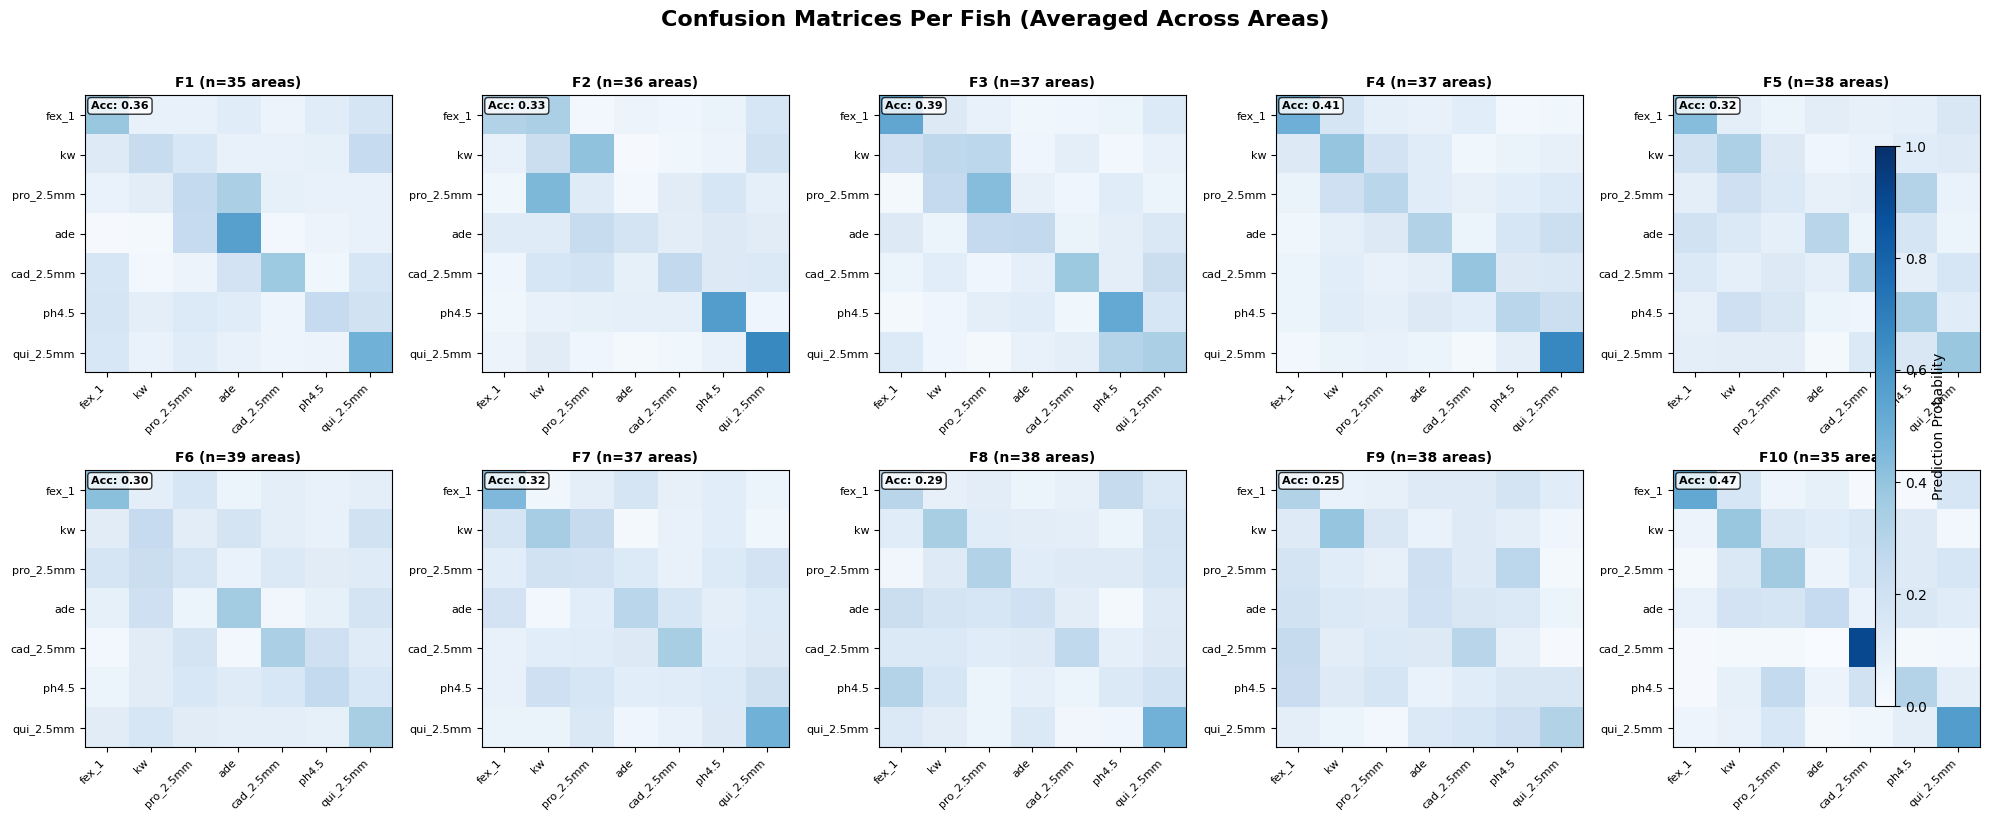


✓ Per-fish confusion matrices plotted
  10 fish shown


In [19]:
# Show confusion matrix for each fish (averaged across areas within fish)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for fish_idx, (fish_key, fish_conf_dict) in enumerate(all_odor_conf_matrices.items()):
    ax = axes[fish_idx]
    
    # Aggregate across areas for this fish
    fish_cm = np.zeros((len(ORDERED_STIMULI), len(ORDERED_STIMULI)))
    n_areas = 0
    
    for area, conf_data in fish_conf_dict.items():
        fish_cm += conf_data['confusion_matrix']
        n_areas += 1
    
    # Average and normalize
    fish_cm_avg = fish_cm / n_areas
    fish_cm_norm = fish_cm_avg / fish_cm_avg.sum(axis=1, keepdims=True)
    
    # Plot
    im = ax.imshow(fish_cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    
    # Labels
    ax.set_xticks(range(len(ORDERED_STIMULI)))
    ax.set_yticks(range(len(ORDERED_STIMULI)))
    ax.set_xticklabels(ORDERED_STIMULI, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ORDERED_STIMULI, fontsize=8)
    
    # Title with fish ID
    simple_id = simplified_fish_ids[fish_key]
    ax.set_title(f'{simple_id} (n={n_areas} areas)', fontsize=10, fontweight='bold')
    
    # Add accuracy in corner
    accuracy = np.trace(fish_cm_norm) / len(ORDERED_STIMULI)
    ax.text(0.02, 0.98, f'Acc: {accuracy:.2f}', 
            transform=ax.transAxes, fontsize=8, fontweight='bold',
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add overall title
fig.suptitle('Confusion Matrices Per Fish (Averaged Across Areas)', 
            fontsize=16, fontweight='bold', y=1.02)

# Add shared colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.01, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Prediction Probability')

plt.tight_layout()
plt.show()

print("\n✓ Per-fish confusion matrices plotted")
print(f"  {len(all_odor_conf_matrices)} fish shown")


#### Confusion Matrix for Significant Areas Only


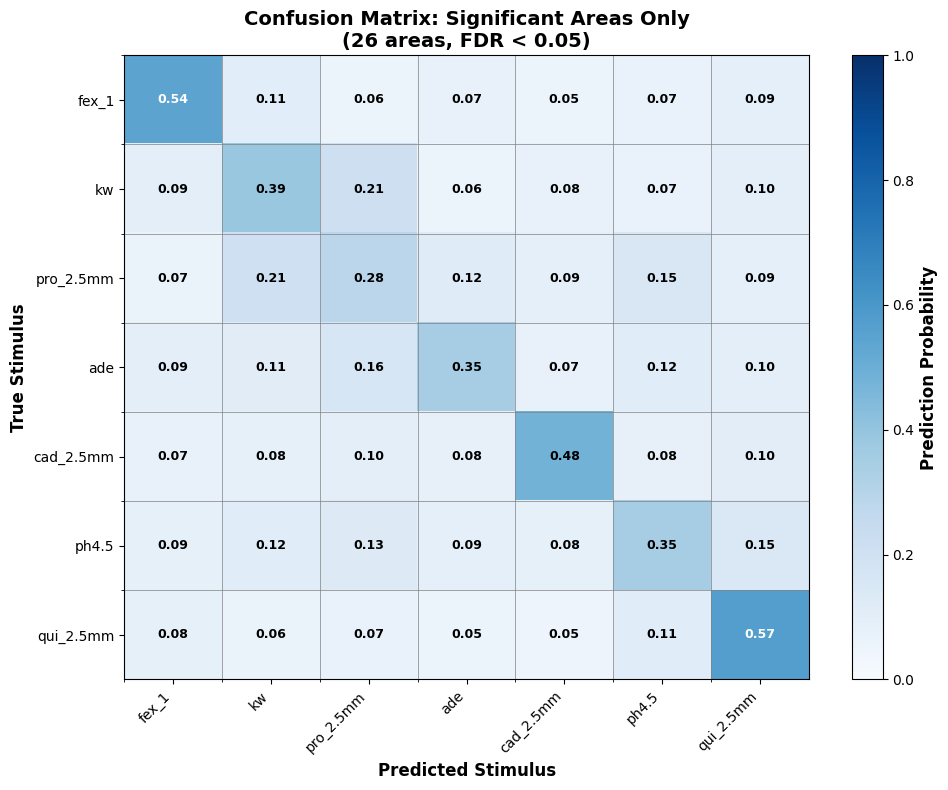


✓ Confusion matrix for 26 significant areas
  Aggregated from 257 confusion matrices
  Average diagonal accuracy: 0.423
  Chance level: 0.143


In [20]:
# Focus on areas with significant discrimination (FDR < 0.05)
sig_areas_list = df_odor_combined[df_odor_combined['is_significant']]['area'].tolist()

if len(sig_areas_list) > 0:
    # Aggregate confusion matrices from significant areas only
    sig_cm = np.zeros((len(ORDERED_STIMULI), len(ORDERED_STIMULI)))
    n_sig_matrices = 0
    
    for fish_id, fish_conf_dict in all_odor_conf_matrices.items():
        for area, conf_data in fish_conf_dict.items():
            if area in sig_areas_list:
                sig_cm += conf_data['confusion_matrix']
                n_sig_matrices += 1
    
    # Average and normalize
    sig_cm_avg = sig_cm / n_sig_matrices
    sig_cm_norm = sig_cm_avg / sig_cm_avg.sum(axis=1, keepdims=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sig_cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Prediction Probability', fontsize=12, fontweight='bold')
    
    ax.set_xticks(range(len(ORDERED_STIMULI)))
    ax.set_yticks(range(len(ORDERED_STIMULI)))
    ax.set_xticklabels(ORDERED_STIMULI, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ORDERED_STIMULI, fontsize=10)
    ax.set_xlabel('Predicted Stimulus', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Stimulus', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix: Significant Areas Only\n({len(sig_areas_list)} areas, FDR < {FDR_ALPHA})', 
                fontsize=14, fontweight='bold')
    
    # Add text annotations
    for i in range(len(ORDERED_STIMULI)):
        for j in range(len(ORDERED_STIMULI)):
            text = ax.text(j, i, f'{sig_cm_norm[i, j]:.2f}',
                          ha="center", va="center",
                          color="white" if sig_cm_norm[i, j] > 0.5 else "black",
                          fontsize=9, fontweight='bold')
    
    # Gridlines
    ax.set_xticks(np.arange(len(ORDERED_STIMULI)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(ORDERED_STIMULI)) - 0.5, minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Confusion matrix for {len(sig_areas_list)} significant areas")
    print(f"  Aggregated from {n_sig_matrices} confusion matrices")
    
    # Calculate diagonal accuracy
    diagonal_acc = np.trace(sig_cm_norm) / len(ORDERED_STIMULI)
    print(f"  Average diagonal accuracy: {diagonal_acc:.3f}")
    print(f"  Chance level: {1/len(ORDERED_STIMULI):.3f}")
    
else:
    print("\nNo significant areas found (FDR < 0.05)")


#### Analysis: Which Odors Are Confused?


In [21]:
# Analyze confusion patterns
print("="*80)
print("CONFUSION ANALYSIS")
print("="*80)

# Use aggregate confusion matrix
cm_norm = aggregate_cm_avg / aggregate_cm_avg.sum(axis=1, keepdims=True)

# Find top confusions (off-diagonal)
confusion_pairs = []
for i in range(len(ORDERED_STIMULI)):
    for j in range(len(ORDERED_STIMULI)):
        if i != j:  # Off-diagonal only
            confusion_pairs.append((
                ORDERED_STIMULI[i], 
                ORDERED_STIMULI[j], 
                cm_norm[i, j]
            ))

# Sort by confusion probability
confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 10 Confusion Pairs (True → Predicted):")
print("-"*80)
for i, (true_stim, pred_stim, prob) in enumerate(confusion_pairs[:10], 1):
    print(f"{i:2d}. {true_stim:12s} → {pred_stim:12s}  (p={prob:.3f})")

# Categorize by valence
attractive = ['fex_1', 'kw', 'pro_2.5mm']
aversive = ['ade', 'cad_2.5mm', 'ph4.5', 'qui_2.5mm']

# Within-valence confusions
within_attractive = [p for p in confusion_pairs if p[0] in attractive and p[1] in attractive]
within_aversive = [p for p in confusion_pairs if p[0] in aversive and p[1] in aversive]
cross_valence = [p for p in confusion_pairs if (p[0] in attractive and p[1] in aversive) or 
                                                  (p[0] in aversive and p[1] in attractive)]

print("\n" + "="*80)
print("VALENCE-BASED CONFUSION ANALYSIS")
print("="*80)

print(f"\nWithin-attractive confusions (n={len(within_attractive)}):")
avg_within_attr = np.mean([p[2] for p in within_attractive]) if within_attractive else 0
print(f"  Average probability: {avg_within_attr:.3f}")
if within_attractive:
    print(f"  Top 3:")
    for i, (t, p, prob) in enumerate(within_attractive[:3], 1):
        print(f"    {i}. {t} → {p}: {prob:.3f}")

print(f"\nWithin-aversive confusions (n={len(within_aversive)}):")
avg_within_aver = np.mean([p[2] for p in within_aversive]) if within_aversive else 0
print(f"  Average probability: {avg_within_aver:.3f}")
if within_aversive:
    print(f"  Top 3:")
    for i, (t, p, prob) in enumerate(within_aversive[:3], 1):
        print(f"    {i}. {t} → {p}: {prob:.3f}")

print(f"\nCross-valence confusions (n={len(cross_valence)}):")
avg_cross = np.mean([p[2] for p in cross_valence]) if cross_valence else 0
print(f"  Average probability: {avg_cross:.3f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
if avg_within_attr > avg_cross or avg_within_aver > avg_cross:
    print("✓ Confusions are MORE common within same valence")
    print("  → Neural patterns encode valence structure")
else:
    print("✓ Confusions are NOT structured by valence")
    print("  → Neural patterns encode odor identity independently")


CONFUSION ANALYSIS

Top 10 Confusion Pairs (True → Predicted):
--------------------------------------------------------------------------------
 1. pro_2.5mm    → kw            (p=0.202)
 2. kw           → pro_2.5mm     (p=0.189)
 3. pro_2.5mm    → ph4.5         (p=0.155)
 4. ade          → pro_2.5mm     (p=0.155)
 5. ph4.5        → qui_2.5mm     (p=0.151)
 6. ph4.5        → pro_2.5mm     (p=0.135)
 7. kw           → fex_1         (p=0.131)
 8. ade          → fex_1         (p=0.125)
 9. cad_2.5mm    → qui_2.5mm     (p=0.124)
10. qui_2.5mm    → ph4.5         (p=0.124)

VALENCE-BASED CONFUSION ANALYSIS

Within-attractive confusions (n=6):
  Average probability: 0.135
  Top 3:
    1. pro_2.5mm → kw: 0.202
    2. kw → pro_2.5mm: 0.189
    3. kw → fex_1: 0.131

Within-aversive confusions (n=12):
  Average probability: 0.104
  Top 3:
    1. ph4.5 → qui_2.5mm: 0.151
    2. cad_2.5mm → qui_2.5mm: 0.124
    3. qui_2.5mm → ph4.5: 0.124

Cross-valence confusions (n=24):
  Average probability: 0.1

#### Save Confusion Matrix Data


In [ ]:
# Save aggregate confusion matrix
cm_output_file = f"{OUTPUT_DIR}/aggregate_confusion_matrix_7odors.csv"

# Create DataFrame
cm_df = pd.DataFrame(
    aggregate_cm_avg,
    index=ORDERED_STIMULI,
    columns=ORDERED_STIMULI
)

cm_df.to_csv(cm_output_file)

print(f"✓ Confusion matrix saved to:")
print(f"  {cm_output_file}")

# Also save normalized version
cm_norm_output = f"{OUTPUT_DIR}/aggregate_confusion_matrix_7odors_normalized.csv"
cm_norm_df = pd.DataFrame(
    cm_normalized,
    index=ORDERED_STIMULI,
    columns=ORDERED_STIMULI
)
cm_norm_df.to_csv(cm_norm_output)

print(f"  {cm_norm_output}")
print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*80)


## 4. Valence Template Matching Analysis

**Goal:** Test if valence-encoding neurons can discriminate attractive from aversive stimuli

**Neuron Selection:**
- Load neurons with significant valence correlations (FDR < 0.05)
- From previous correlation analysis

**Binary Classification:**
- **Class 0 (Aversive):** ade, cad_2.5mm, qui_2.5mm
- **Class 1 (Attractive):** fex_1, kw, pro_2.5mm

**Method:**
- Same as odor analysis, but only valence neurons
- Binary classification instead of 7-way


### Load Valence Neurons


In [ ]:
# Load pre-identified valence neurons
pos = pd.read_csv(POS_VALENCE_PATH)
pos['neuron_id'] = pos['fish_id'] + pos['neuron_id']

neg = pd.read_csv(NEG_VALENCE_PATH)
neg['neuron_id'] = neg['fish_id'] + neg['neuron_id']

# Combine significant valence neurons (FDR < 0.05)
valence_neurons = set(
    pos[pos['p_fdr'] < FDR_ALPHA]['neuron_id']
).union(
    neg[neg['p_fdr'] < FDR_ALPHA]['neuron_id']
)

print(f"✓ Loaded valence neurons")
print(f"  Positive valence: {len(pos[pos['p_fdr'] < FDR_ALPHA])}")
print(f"  Negative valence: {len(neg[neg['p_fdr'] < FDR_ALPHA])}")
print(f"  Total unique: {len(valence_neurons)}")


### Initialize Storage


In [ ]:
# Storage for valence results
all_valence_results = {}

print(f"\nStarting valence analysis for {len(FISH_IDS)} fish...")
print(f"Analyzing {len(SELECTED_STIMULI_VALENCE)} stimuli")
print(f"Binary classification: Attractive (1) vs Aversive (0)")


### Main Processing Loop: For Each Fish


In [ ]:
# Process each fish
for fish_num, (fb_id, hb_id) in enumerate(FISH_IDS, 1):
    print(f"\n{'='*80}")
    print(f"Fish {fish_num}/{len(FISH_IDS)}: {fb_id}, {hb_id}")
    print(f"{'='*80}")
    
    # Load data
    data_fb = pd.read_hdf(NEURAL_DATA_PATH, where=f'fish_id == "{fb_id}"')
    data_hb = pd.read_hdf(NEURAL_DATA_PATH, where=f'fish_id == "{hb_id}"')
    data = pd.concat([data_fb, data_hb])
    
    # Filter for valence stimuli
    filtered_df = data[data['stimulus'].isin(SELECTED_STIMULI_VALENCE)].copy()
    
    # Parse coordinates
    filtered_df['coords'] = filtered_df['coords_serialised'].apply(
        lambda x: np.asarray(json.loads(x))
    )
    filtered_df['neuron_id'] = filtered_df['fish_id'] + filtered_df['neuron_id']
    filtered_df.drop('coords_serialised', axis=1, inplace=True)
    
    # Assign nMLF
    filtered_df['area'] = filtered_df.apply(
        lambda row: 'nMLF' if is_within_3d_mask(row['coords'], nMLF) else row['area'],
        axis=1
    )
    
    # Filter for valence neurons only
    valence_df = filtered_df[filtered_df['neuron_id'].isin(valence_neurons)]
    
    print(f"  Valence neurons in this fish: {valence_df['neuron_id'].nunique()}")
    
    unique_areas = valence_df['area'].unique()
    fish_results = {}
    
    # Process each area
    for area_num, area in enumerate(unique_areas, 1):
        area_df = valence_df.query("area == @area")
        
        # Pivot
        df_resp = area_df.pivot_table(
            index=['fish_id', 'neuron_id'],
            columns=['stimulus', 'trial_number'],
            values='resp'
        )
        
        # Map to valence labels
        columns = df_resp.columns
        stimulus_names = [col[0] for col in columns]
        valence_labels = [VALENCE_MAP[stim] for stim in stimulus_names]
        
        # Remove neurons with NaN
        resp_clean = df_resp.dropna()
        
        if len(resp_clean) < MIN_NEURONS_VALENCE:
            continue
        
        print(f"    [{area_num}/{len(unique_areas)}] {area}: {len(resp_clean)} neurons")
        
        # Prepare data
        X = resp_clean.values.T
        y = np.array(valence_labels)
        
        # Classification with CV
        cv_result = template_matching_cross_validation(
            X, y, labels=[0, 1], n_splits=N_FOLDS_VALENCE
        )
        mean_accuracy = cv_result['mean_score']
        
        # Permutation test
        p_value = permutation_test(
            X, y, labels=[0, 1],
            n_splits=N_FOLDS_VALENCE,
            n_permutations=N_PERMUTATIONS
        )
        
        # Store
        fish_results[area] = {
            'mean_score': mean_accuracy,
            'p_value': p_value,
            'n_neurons': len(resp_clean)
        }
        
        print(f"      Accuracy: {mean_accuracy:.3f}, p-value: {p_value:.4f}")
    
    # Store fish results
    fish_key = f"{fb_id}_{hb_id}"
    all_valence_results[fish_key] = fish_results
    
    print(f"  Completed {len(fish_results)} areas")

print(f"\n{'='*80}")
print(f"✓ Valence analysis complete")
print(f"{'='*80}")


### Statistical Combination


In [ ]:
# Reorganize by area
all_areas_valence = {}

for fish_id, fish_results in all_valence_results.items():
    for area_name, area_results in fish_results.items():
        mean_score = area_results['mean_score']
        p_value = area_results['p_value']
        
        if area_name not in all_areas_valence:
            all_areas_valence[area_name] = []
        
        all_areas_valence[area_name].append((fish_id, mean_score, p_value))

print(f"\nCombining valence statistics...")
print(f"  Total areas: {len(all_areas_valence)}")

# Fisher's + FDR
df_valence_combined = combine_fish_statistics(all_areas_valence, fdr_alpha=FDR_ALPHA)

# Display
print(f"\n{'='*80}")
print("VALENCE TEMPLATE MATCHING RESULTS")
print(f"{'='*80}")
sig_areas_val = df_valence_combined[df_valence_combined['is_significant']]
print(f"\nSignificant areas (FDR < {FDR_ALPHA}):")
print(f"  {len(sig_areas_val)}/{len(df_valence_combined)} areas")

if len(sig_areas_val) > 0:
    print(f"\nTop 10:")
    print(sig_areas_val[['area', 'mean_accuracy', 'fdr_corrected']].head(10).to_string(index=False))

print(f"\nAccuracy statistics:")
print(f"  Mean: {df_valence_combined['mean_accuracy'].mean():.3f}")
print(f"  Range: {df_valence_combined['mean_accuracy'].min():.3f} - {df_valence_combined['mean_accuracy'].max():.3f}")
print(f"  Chance: 0.500 (binary classification)")


### Visualization: Valence Results


In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

area_indices_val = {area: i for i, area in enumerate(df_valence_combined['area'])}
sorted_areas_val = list(df_valence_combined['area'])

# Plot individual fish
labels_handled = set()
for area in sorted_areas_val:
    if area not in all_areas_valence:
        continue
    
    fish_results = all_areas_valence[area]
    y_values = [area_indices_val[area]] * len(fish_results)
    jittered_y = jitter(np.array(y_values, dtype=float), amount=0.3)
    
    for y, (fish_id, score, p_value) in zip(jittered_y, fish_results):
        simple_id = simplified_fish_ids[fish_id]
        fish_idx = list(simplified_fish_ids.values()).index(simple_id)
        
        alpha = 1.0 if p_value < 0.05 else 0.3
        marker_size = 60 if p_value < 0.05 else 30
        
        if simple_id not in labels_handled:
            ax.scatter(score, y, c=[fish_colors[fish_idx]],
                      alpha=alpha, s=marker_size, label=simple_id)
            labels_handled.add(simple_id)
        else:
            ax.scatter(score, y, c=[fish_colors[fish_idx]],
                      alpha=alpha, s=marker_size)

# Mean ± std
means_val = [df_valence_combined[df_valence_combined['area']==area]['mean_accuracy'].values[0]
            for area in sorted_areas_val]
stds_val = [df_valence_combined[df_valence_combined['area']==area]['std_accuracy'].values[0]
           for area in sorted_areas_val]

ax.errorbar(means_val, range(len(sorted_areas_val)), xerr=stds_val,
           fmt='none', ecolor='black', elinewidth=2, capsize=4, alpha=0.7)
ax.scatter(means_val, range(len(sorted_areas_val)), c='black', s=100,
          marker='D', zorder=10, label='Mean')

# Chance
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Chance (0.50)')

# Formatting
ax.set_yticks(range(len(sorted_areas_val)))
ax.set_yticklabels(sorted_areas_val, fontsize=9)
ax.set_xlabel('Classification Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Brain Area', fontsize=12, fontweight='bold')
ax.set_title('Valence Template Matching: Attractive vs Aversive Classification',
            fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")


### Save Valence Results


In [ ]:
# Save
output_file_valence = f"{OUTPUT_DIR}/combined_valence_template_matching_refactored.csv"
df_valence_combined.to_csv(output_file_valence, index=False)

print(f"✓ Valence results saved to:")
print(f"  {output_file_valence}")
print(f"  Rows: {len(df_valence_combined)}")
print(f"  Significant: {df_valence_combined['is_significant'].sum()}")


## 5. Analysis Complete!

### Summary of Results:

**Odor Template Matching:**
- Tested discrimination of 7 odor identities
- Analyzed ~35 brain areas × 10 fish
- Statistical rigor: Cross-validation + permutation + Fisher's + FDR

**Valence Template Matching:**
- Tested discrimination of attractive vs aversive
- Analyzed valence neurons only
- Binary classification

### Output Files:
1. Odor results CSV
2. Valence results CSV

### Key Findings:
- Check which areas show significant discrimination (FDR < 0.05)
- Compare accuracy to chance levels
- Examine confusion patterns (which stimuli are confused?)

### Next Steps:
- Analyze confusion matrices for systematic errors
- Compare odor vs valence encoding areas
- Investigate neurons in significant areas


In [ ]:
# Final summary
print("="*80)
print("TEMPLATE MATCHING ANALYSIS COMPLETE")
print("="*80)
print(f"\n✓ Odor analysis:")
print(f"    Areas analyzed: {len(df_odor_combined)}")
print(f"    Significant: {df_odor_combined['is_significant'].sum()}")
print(f"    Mean accuracy: {df_odor_combined['mean_accuracy'].mean():.3f}")
print(f"\n✓ Valence analysis:")
print(f"    Areas analyzed: {len(df_valence_combined)}")
print(f"    Significant: {df_valence_combined['is_significant'].sum()}")
print(f"    Mean accuracy: {df_valence_combined['mean_accuracy'].mean():.3f}")
print(f"\n✓ Output files saved to {OUTPUT_DIR}")
print("="*80)
